Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


Verify dataset structure

In [2]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [3]:
df.columns = df.columns.str.strip()

Check target variable

In [4]:
df["Outcome"].value_counts()


Outcome
0    1316
1     684
Name: count, dtype: int64

Check for invalid zeros

In [5]:
(df == 0).sum()

Pregnancies                  301
Glucose                       13
BloodPressure                 90
SkinThickness                573
Insulin                      956
BMI                           28
DiabetesPedigreeFunction       0
Age                            0
Outcome                     1316
dtype: int64

In [6]:
df1 = df.copy()

Clean the dataset

In [7]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    df1[col] = df1[col].replace(0, df1[col].median())

EDA

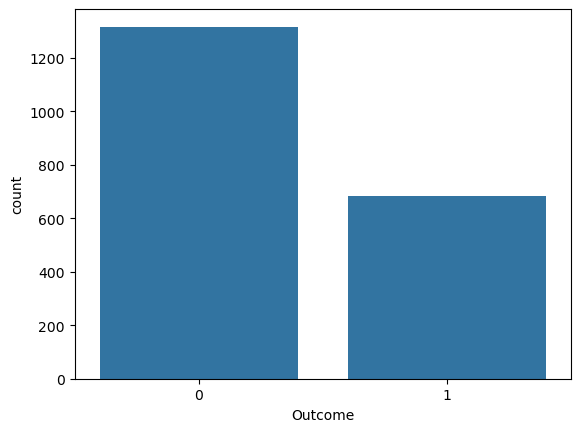

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Outcome", data=df1)
plt.show()

Train/Test Split

In [9]:
from sklearn.model_selection import train_test_split

X = df1.drop("Outcome", axis=1)
y = df1["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Feature Scaling

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Models: 
1. Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


2. Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)  # no scaling needed

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


3. Support Vector Machine

In [13]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Evaluation:

In [14]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": lr.predict(X_test_scaled),
    "Random Forest": rf.predict(X_test),
    "SVM": svm.predict(X_test_scaled)
}

for name, preds in models.items():
    print(name, "Accuracy:", accuracy_score(y_test, preds))

Logistic Regression Accuracy: 0.7875
Random Forest Accuracy: 0.985
SVM Accuracy: 0.86


In [15]:
from sklearn.metrics import classification_report

for name, preds in models.items():
    print(f"\n{name}")
    print(classification_report(y_test, preds))


Logistic Regression
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       263
           1       0.75      0.57      0.65       137

    accuracy                           0.79       400
   macro avg       0.78      0.74      0.75       400
weighted avg       0.78      0.79      0.78       400


Random Forest
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       263
           1       0.98      0.98      0.98       137

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400


SVM
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       263
           1       0.84      0.73      0.78       137

    accuracy                           0.86       400
   macro avg       0.85      0.83      0.84       400
weighted avg       0.86      0.86

Confusion Matrix

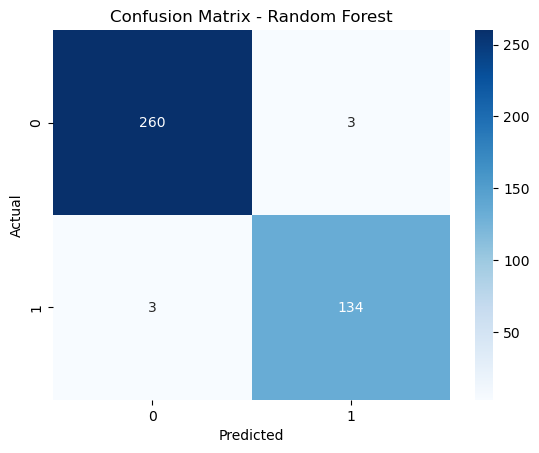

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

Check Feature Importance

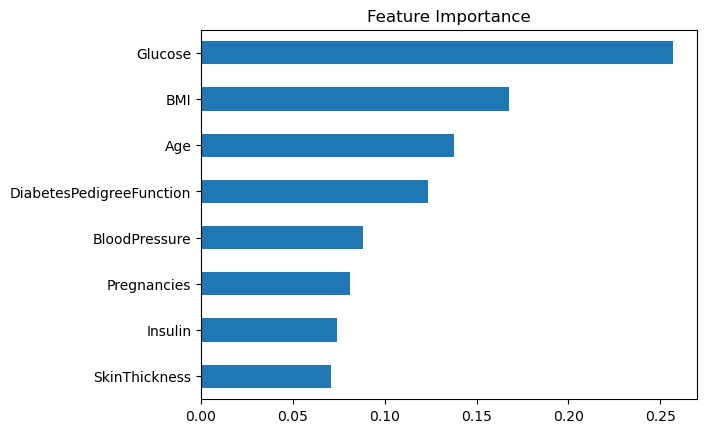

In [17]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

Test Prediction

In [18]:
sample = X_test.iloc[0:1]
print("Prediction:", rf.predict(sample))

Prediction: [0]


Cross Validation

In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.994


Hyperparameter Tuning

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 100}
